In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Leitura
df = pd.read_parquet('../../dataset/data.parquet', engine='fastparquet')
df = df[df['Desired_Savings'] > 0].copy()


df['Taxa_Endividamento'] = df['Loan_Repayment'] / df['Income']

# Nova Regra: Sobra menos de 10% da renda no fim do mês? (Margem Crítica)
df['Sobra_Critica'] = (df['Disposable_Income'] / df['Income'] < 0.10).astype(int)

# Target: É vulnerável se compromete mais de 15% com dívidas OU tem sobra crítica (< 10%)
df['Vulnerable'] = ((df['Taxa_Endividamento'] > 0.10) | (df['Sobra_Critica'] == 1)).astype(int)


# ==========================================
# PASSO 2: AS FEATURES (COMPORTAMENTO)
# Transformando TUDO em proporção da renda para o modelo comparar na mesma escala.
# ==========================================

# A. Gastos Essenciais
df['Rent_Ratio'] = df['Rent'] / df['Income']
df['Healthcare_Ratio'] = df['Healthcare'] / df['Income']
df['Education_Ratio'] = df['Education'] / df['Income']
df['Groceries_Ratio'] = df['Groceries'] / df['Income']
df['Transport_Ratio'] = df['Transport'] / df['Income']
df['Utilities_Ratio'] = df['Utilities'] / df['Income']
df['Insurance_Ratio'] = df['Insurance'] / df['Income']

# B. Gastos Discricionários (Fundamentais para o modelo entender o estilo de vida)
df['Eating_Out_Ratio'] = df['Eating_Out'] / df['Income']
df['Entertainment_Ratio'] = df['Entertainment'] / df['Income']
df['Misc_Ratio'] = df['Miscellaneous'] / df['Income']


# ==========================================
# PASSO 3: SELEÇÃO E DIVISÃO (BLINDAGEM CONTRA LEAKAGE)
# O modelo não enxerga a Dívida (Loan_Repayment) nem a Sobra (Disposable_Income).
# Ele precisa deduzir a vulnerabilidade analisando o estilo de vida.
# ==========================================
features = [
    'Age', 'Dependents',                 # Demografia
    'Rent_Ratio', 'Healthcare_Ratio',    # Essenciais
    'Education_Ratio', 'Groceries_Ratio',
    'Transport_Ratio', 'Utilities_Ratio', 
    'Insurance_Ratio',
    'Eating_Out_Ratio', 'Entertainment_Ratio', # Lazer/Supérfluos
    'Misc_Ratio'
]

X = df[features]
y = df['Vulnerable']

# Divisão
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

--- Nova Distribuição Absoluta ---
Vulnerable
0    14583
1     5305
Name: count, dtype: int64

--- Nova Distribuição Percentual (%) ---
Vulnerable
0    73.33
1    26.67
Name: proportion, dtype: float64


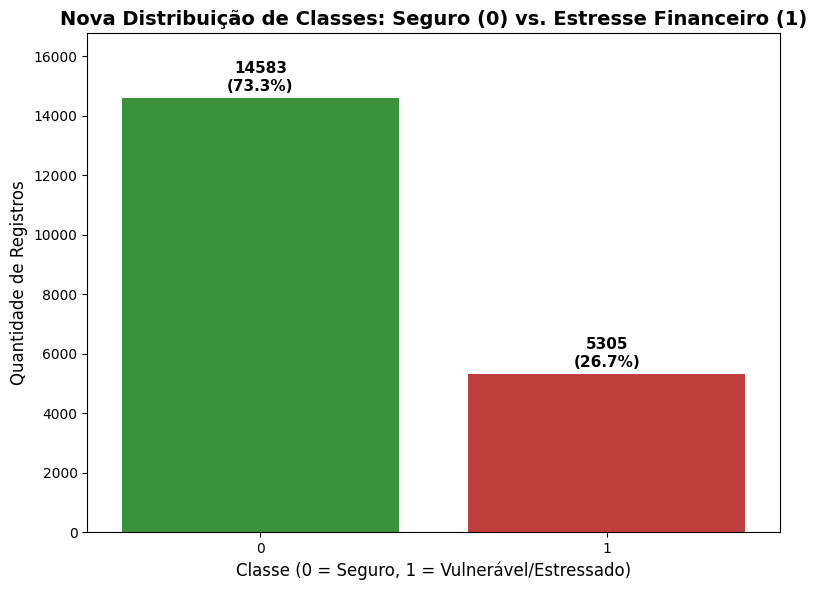

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculando a distribuição absoluta e percentual
contagem = df['Vulnerable'].value_counts()
percentual = df['Vulnerable'].value_counts(normalize=True) * 100

print("--- Nova Distribuição Absoluta ---")
print(contagem)
print("\n--- Nova Distribuição Percentual (%) ---")
print(percentual.round(2))

# 2. Visualização gráfica da distribuição
plt.figure(figsize=(8, 6))

# Gráfico de barras com as novas classes
ax = sns.countplot(
    x='Vulnerable', 
    data=df, 
    palette=['#2ca02c', '#d62728'], # Verde (Seguro), Vermelho (Vulnerável)
    hue='Vulnerable',
    legend=False
)

# Adicionando os rótulos de dados
total = len(df)
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        porcentagem = f'{(altura/total)*100:.1f}%'
        texto = f'{int(altura)}\n({porcentagem})'
        ax.annotate(
            texto, 
            (p.get_x() + p.get_width() / 2., altura),
            ha='center', 
            va='center', 
            xytext=(0, 15), 
            textcoords='offset points',
            fontsize=11, 
            fontweight='bold'
        )

plt.title('Nova Distribuição de Classes: Seguro (0) vs. Estresse Financeiro (1)', fontsize=14, fontweight='bold')
plt.xlabel('Classe (0 = Seguro, 1 = Vulnerável/Estressado)', fontsize=12)
plt.ylabel('Quantidade de Registros', fontsize=12)

# Espaço extra no topo para as anotações não cortarem
plt.ylim(0, df['Vulnerable'].value_counts().max() * 1.15)

plt.tight_layout()
plt.show()

--- Iniciando Testes Baseline ---
Proporção de Desbalanceamento Calculada: 2.75


TREINANDO E AVALIANDO: XGBoost

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      2917
           1       0.27      0.29      0.28      1061

    accuracy                           0.60      3978
   macro avg       0.50      0.50      0.50      3978
weighted avg       0.61      0.60      0.61      3978



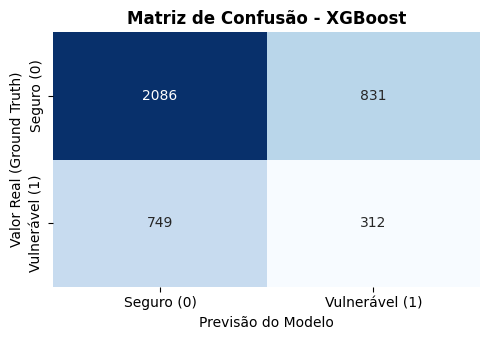


TREINANDO E AVALIANDO: Random Forest

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      2917
           1       0.50      0.00      0.00      1061

    accuracy                           0.73      3978
   macro avg       0.62      0.50      0.42      3978
weighted avg       0.67      0.73      0.62      3978



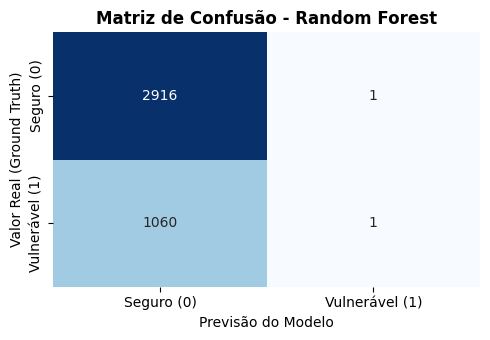


TREINANDO E AVALIANDO: Regressão Logística

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.74      0.50      0.59      2917
           1       0.27      0.51      0.35      1061

    accuracy                           0.50      3978
   macro avg       0.50      0.50      0.47      3978
weighted avg       0.61      0.50      0.53      3978



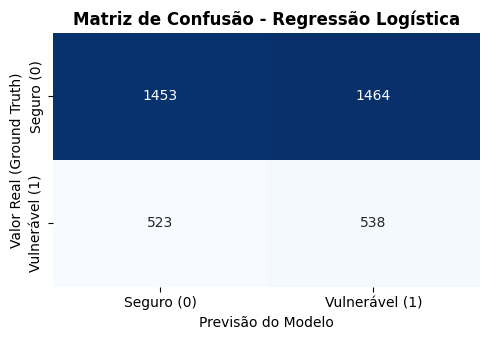

In [6]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cálculo exato do peso da classe minoritária
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
peso_balanceamento = num_neg / num_pos

print(f"--- Iniciando Testes Baseline ---")
print(f"Proporção de Desbalanceamento Calculada: {peso_balanceamento:.2f}\n")

# 2. Escalonamento (Necessário APENAS para a Regressão Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Definição dos Modelos (Apenas com parâmetros padrão e ajuste de peso)
modelos = {
    "XGBoost": xgb.XGBClassifier(
        scale_pos_weight=peso_balanceamento, 
        random_state=42, 
        eval_metric='logloss'
    ),
    "Random Forest": RandomForestClassifier(
        class_weight='balanced', 
        random_state=42
    ),
    "Regressão Logística": LogisticRegression(
        class_weight='balanced', 
        random_state=42, 
        max_iter=1000
    )
}

# 4. Loop de Treinamento e Avaliação
for nome, modelo in modelos.items():
    print(f"\n" + "="*50)
    print(f"TREINANDO E AVALIANDO: {nome}")
    print("="*50)
    
    # Seleciona os dados corretos (escalonados para regressão logística)
    if nome == "Regressão Logística":
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test
        
    # Treina o modelo
    modelo.fit(X_tr, y_train)
    
    # Previsões
    y_pred = modelo.predict(X_te)
    
    # Relatório
    print("\n--- Relatório de Classificação ---")
    print(classification_report(y_test, y_pred))
    
    # Matriz de Confusão
    plt.figure(figsize=(5, 3.5))
    matriz = confusion_matrix(y_test, y_pred)
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=['Seguro (0)', 'Vulnerável (1)'], 
                yticklabels=['Seguro (0)', 'Vulnerável (1)'])
    plt.title(f'Matriz de Confusão - {nome}', fontweight='bold', fontsize=12)
    plt.ylabel('Valor Real (Ground Truth)')
    plt.xlabel('Previsão do Modelo')
    plt.tight_layout()
    plt.show()